##### In this notebook, we try to explore how and if we can create a plot of H(z) vs z for different redshift bins.

In [1]:
import json
import pandas as pd
import numpy as np
from plot_util import make_contour

In [7]:
### first let's load in the json file with the data vectors
# with open('../../static_datavectors_seed6.json', 'r') as f:
#     data = json.load(f)
df = pd.read_json('../../static_datavectors_seed6.json')

In [102]:
df.iloc[8]

catalog_idxs                        [393, 236, 130, 1459, 498, 1067, 824, 397, 844...
z_lens                              [0.356, 0.6000000000000001, 0.5, 0.342, 1.336,...
z_src                               [2.8518746, 1.1408646, 1.5745779, 2.293471, 2....
fpd_samples                         [[[-0.07669739330620101, -0.07061371178626401,...
lens_param_samples                  [[[0.8432269184882011, 0.053341520589673, -0.0...
kappa_ext_samples                   [[0.06398417443344401, -0.0034122516290390004,...
beta_ani_samples                                                                  NaN
kin_pred_samples                                                                  NaN
td_measured                         [[[-4.186214726509657, -3.718748253738895, -18...
td_likelihood_prec                  [[[[0.04, 0.0, 0.0], [0.0, 0.04, 0.0], [0.0, 0...
td_likelihood_prefactors            [[-7.585129336916318, -7.585129336916318, -7.5...
lens_params_nu_int_means            [1.42, 0.0, 0.0, 2

In [12]:
### just look at one chunk
index0 = df.iloc[0]

In [15]:
index0.index

Index(['catalog_idxs', 'z_lens', 'z_src', 'fpd_samples', 'lens_param_samples',
       'kappa_ext_samples', 'beta_ani_samples', 'kin_pred_samples',
       'td_measured', 'td_likelihood_prec', 'td_likelihood_prefactors',
       'lens_params_nu_int_means', 'lens_params_nu_int_stddevs',
       'log_prob_lens_param_samps_nu_int', 'sigma_v_measured',
       'sigma_v_likelihood_prec', 'sigma_v_likelihood_prefactors',
       'log_prob_beta_ani_samps_nu_int'],
      dtype='object')

In [46]:
lens_num = 0
store_info = {}
for i in index0.index:
    store_info[i] =index0[i][lens_num]
    try:
        print(len(index0[i][lens_num]))
    except:
        print(i, index0[i][lens_num])

catalog_idxs 448
z_lens 0.8220000000000001
z_src 2.4995654
5000
5000
5000
5000
5000
5000
5000
5000
lens_params_nu_int_means 0.85
lens_params_nu_int_stddevs 0.28
5000
5000
5000
5000
5000


In [50]:
len(samples_5000)

13

Skipping td_measured_1 (no variation)
Skipping td_measured_2 (no variation)
Skipping td_measured_3 (no variation)
Skipping td_likelihood_prefactors (no variation)
Skipping sigma_v_measured_1 (no variation)
Skipping sigma_v_measured_2 (no variation)
Skipping sigma_v_measured_3 (no variation)
Skipping sigma_v_measured_4 (no variation)
Skipping sigma_v_measured_5 (no variation)
Skipping sigma_v_measured_6 (no variation)
Skipping sigma_v_measured_7 (no variation)
Skipping sigma_v_measured_8 (no variation)
Skipping sigma_v_measured_9 (no variation)
Skipping sigma_v_measured_10 (no variation)
Skipping sigma_v_likelihood_prefactors (no variation)

Total parameters with variation: 27
Sample shape: (5000, 27)
Labels: ['fpd_1', 'fpd_2', 'fpd_3', '$\\xi$_1', '$\\xi$_2', '$\\xi$_3', '$\\xi$_4', '$\\xi$_5', '$\\xi$_6', '$\\xi$_7', '$\\xi$_8', '$\\xi$_9', '$\\xi$_10', 'kappa_ext', 'beta_ani', 'K_1', 'K_2', 'K_3', 'K_4', 'K_5', 'K_6', 'K_7', 'K_8', 'K_9', 'K_10', 'log_prob_$\\xi$_samps_nu_int', 'log_

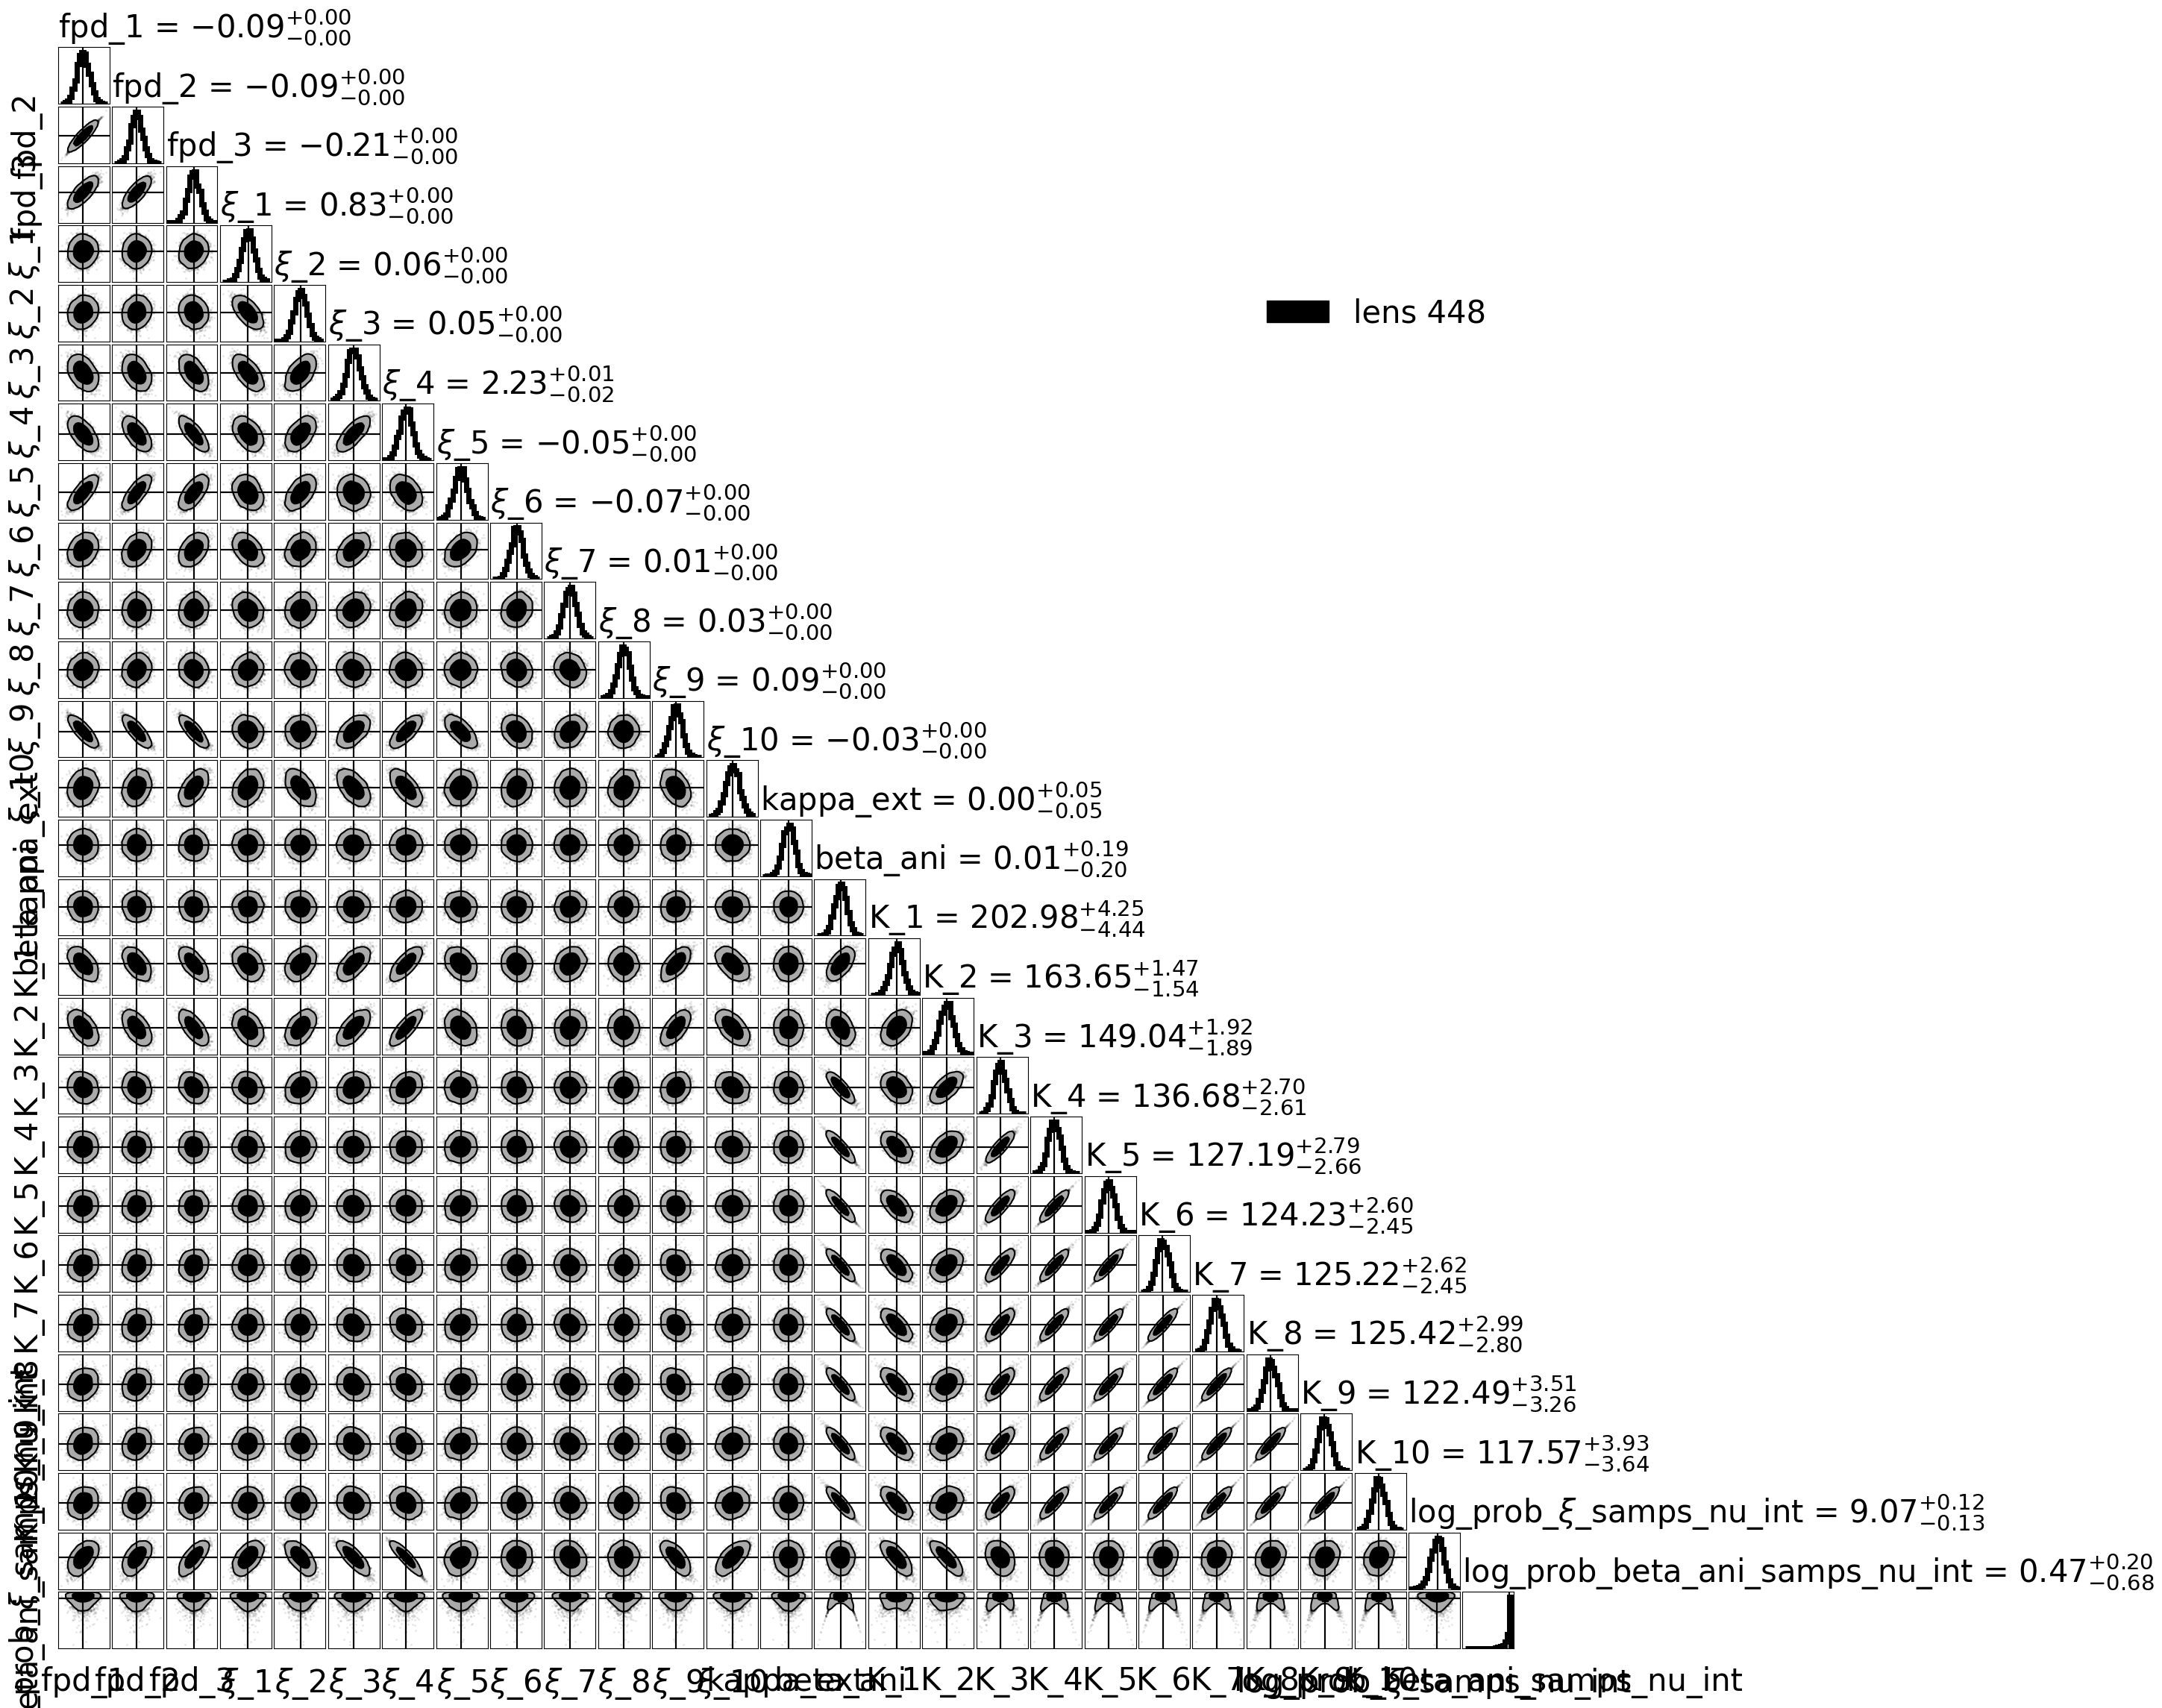

In [67]:
# Collect all samples and split 2D arrays into separate columns
all_samples = []
all_labels = []

for key, value in store_info.items():
    if hasattr(value, "__len__") and len(value) == 5000:
        arr = np.array(value)
        if arr.ndim == 1:
            # 1D array - add directly
            all_samples.append(arr)
            all_labels.append(key)
        elif arr.ndim == 2:
            # 2D array - split into columns
            for i in range(arr.shape[1]):
                all_samples.append(arr[:, i])
                all_labels.append(f"{key}_{i+1}")

# Stack all samples into a single 2D array for corner plot
combined_samples = np.column_stack(all_samples)

# Filter out columns with no dynamic range
filtered_samples = []
filtered_labels = []
for i, label in enumerate(all_labels):
    col = combined_samples[:, i]
    if np.std(col) > 1e-10:  # Has variation
        filtered_samples.append(col)
        filtered_labels.append(label)
    else:
        print(f"Skipping {label} (no variation)")

# Stack filtered samples
final_samples = np.column_stack(filtered_samples)

print(f"\nTotal parameters with variation: {len(filtered_labels)}")
print(f"Sample shape: {final_samples.shape}")
filtered_labels = [i.replace('_samples', '') for i in filtered_labels]
filtered_labels = [i.replace('lens_param', '$\\xi$') for i in filtered_labels]
filtered_labels = [i.replace('kin_pred', 'K') for i in filtered_labels]

print(f"Labels: {filtered_labels}")
fig = make_contour([final_samples], labels=filtered_labels, categories=[f'lens {store_info["catalog_idxs"]}'], colors=['black'])

for ax in fig.axes:
    ax.set_xticks([])
    ax.set_yticks([])

In [32]:
from matplotlib import cm, colors
def random_colors(n, cmap_name="hsv", seed=None):
    rng = np.random.default_rng(seed)
    cmap = cm.get_cmap(cmap_name, n)
    return [colors.to_hex(cmap(i)) for i in rng.integers(0, n, size=n)]
cols = random_colors(len(index0['catalog_idxs']), seed=42)
cols

/var/folders/97/kgg891cd1tg6h957n9nm8rkm0000gn/T/ipykernel_98017/2607956496.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(cmap_name, n)


['#ff0000',
 '#9700ff',
 '#0010ff',
 '#00ff9f',
 '#00ff9f',
 '#ff00bf',
 '#ff0000',
 '#0010ff',
 '#afff00',
 '#ff0000']

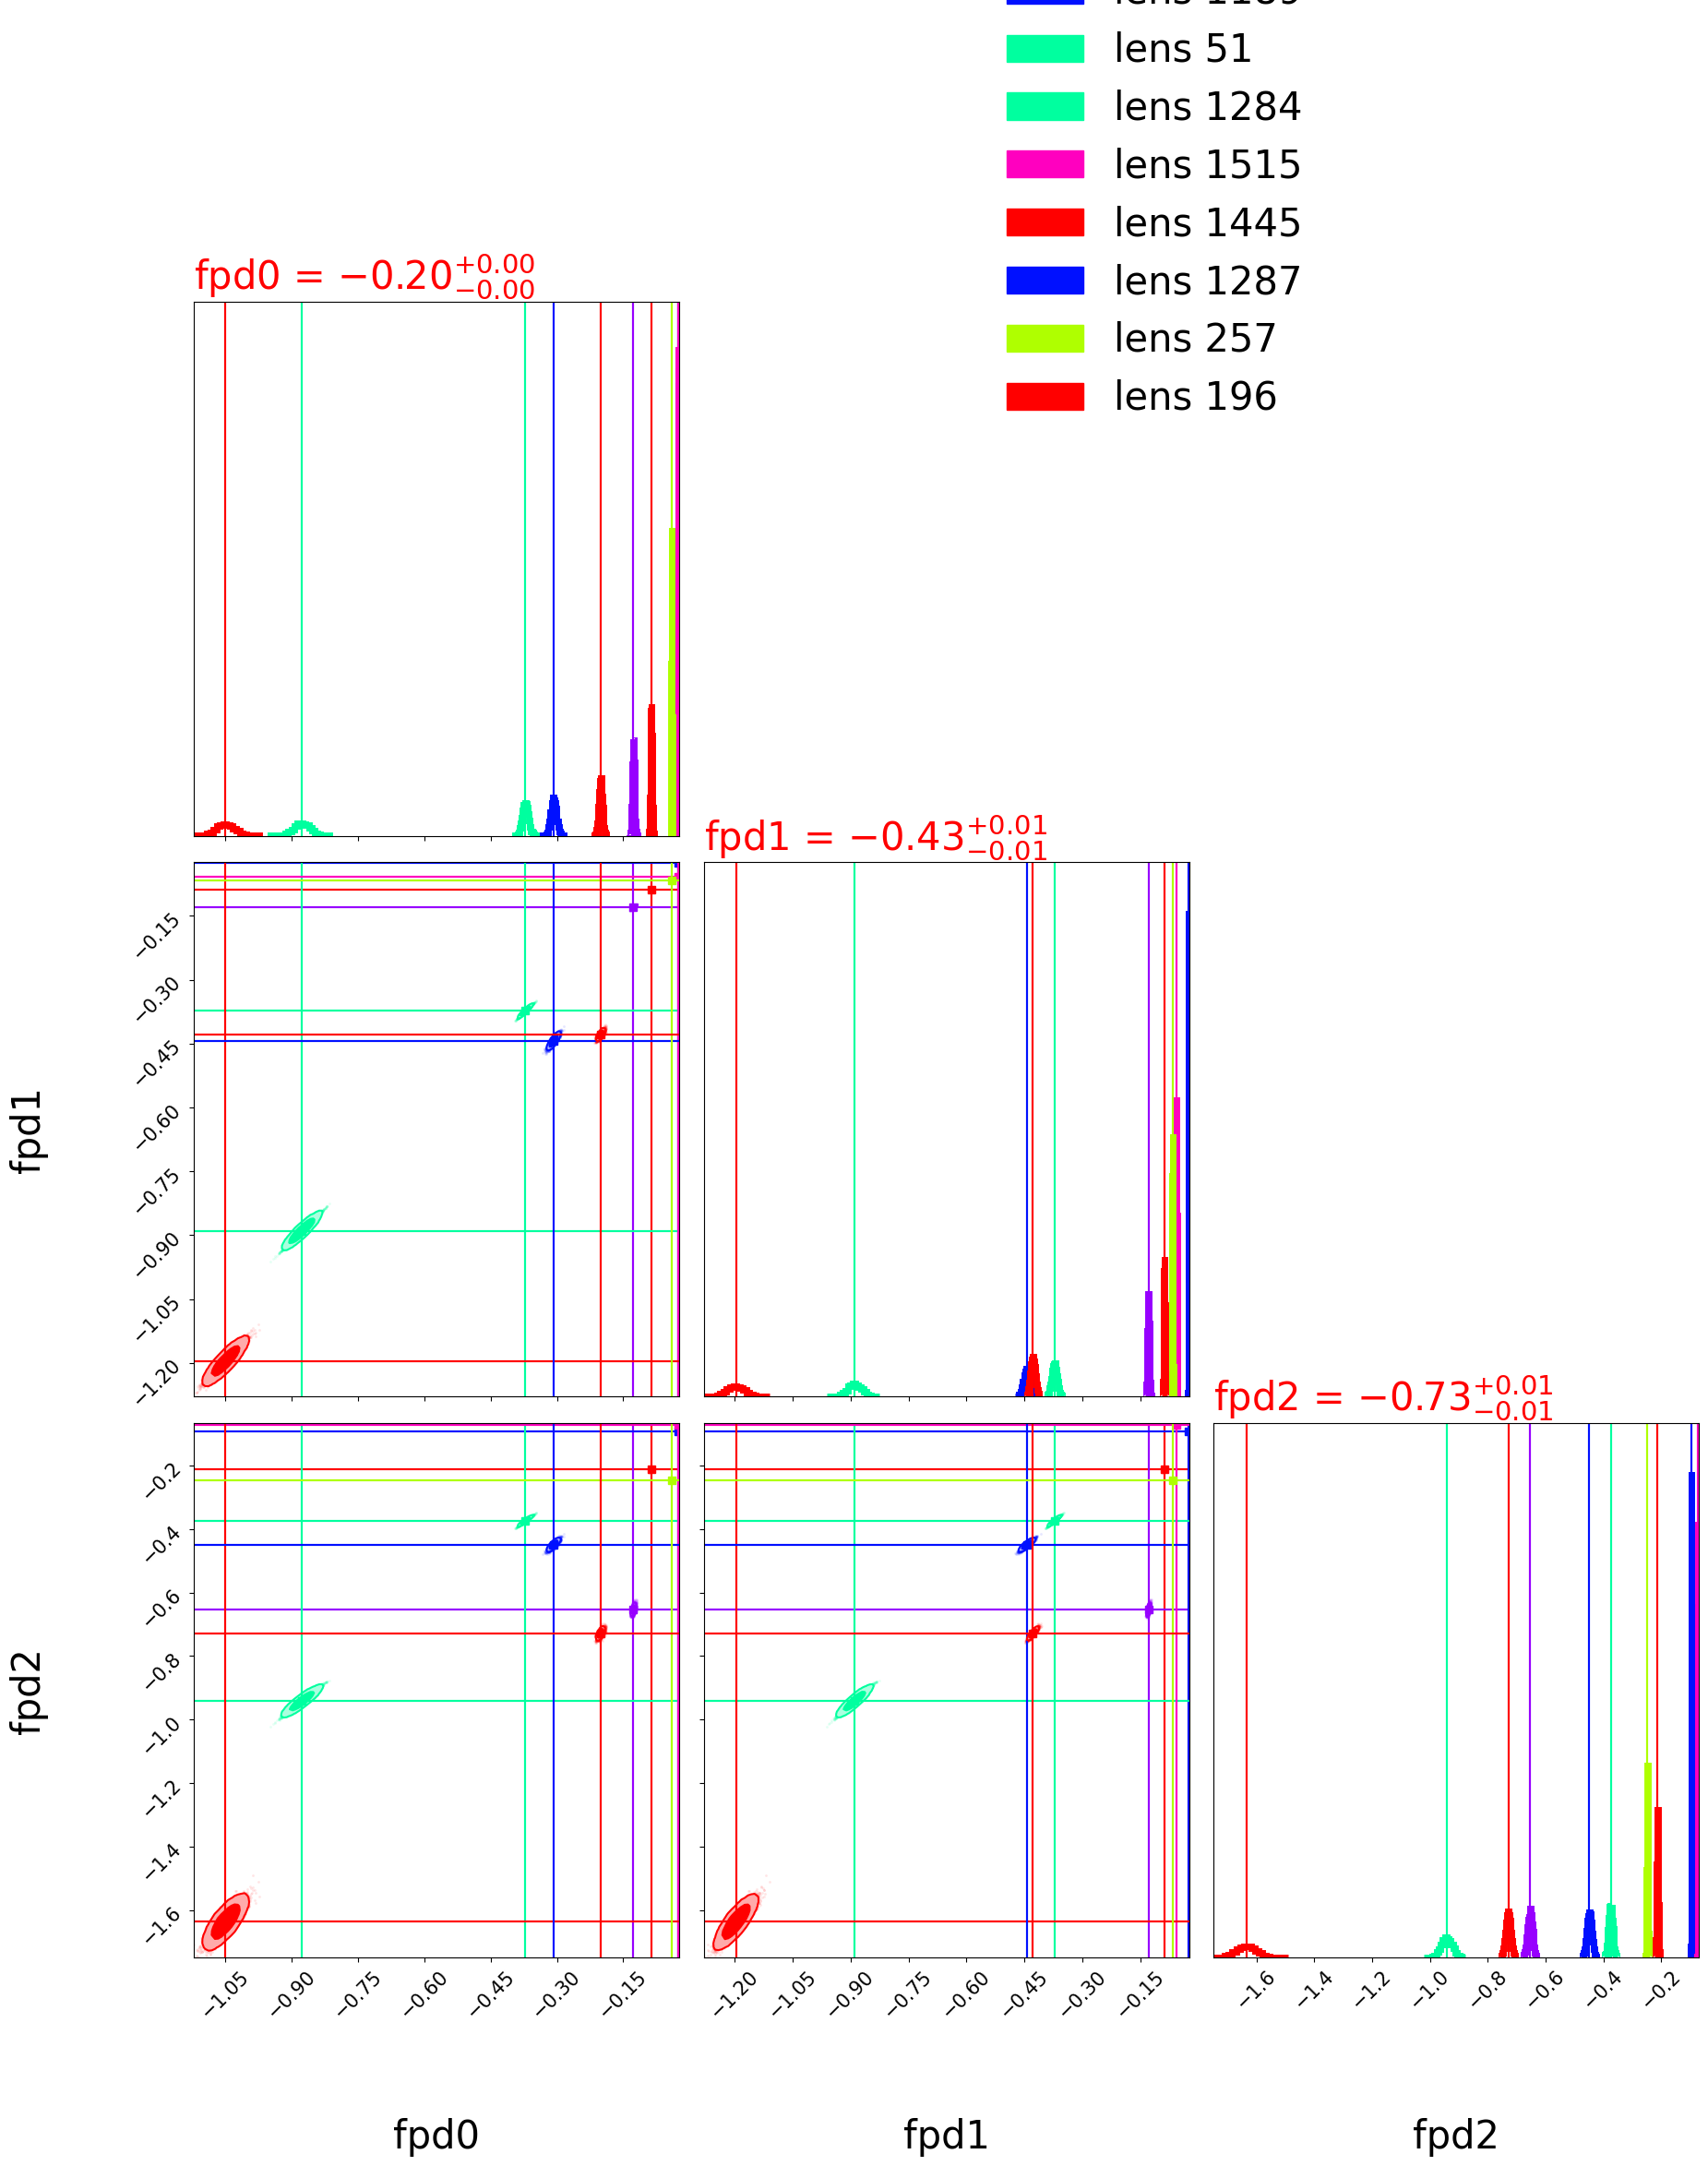

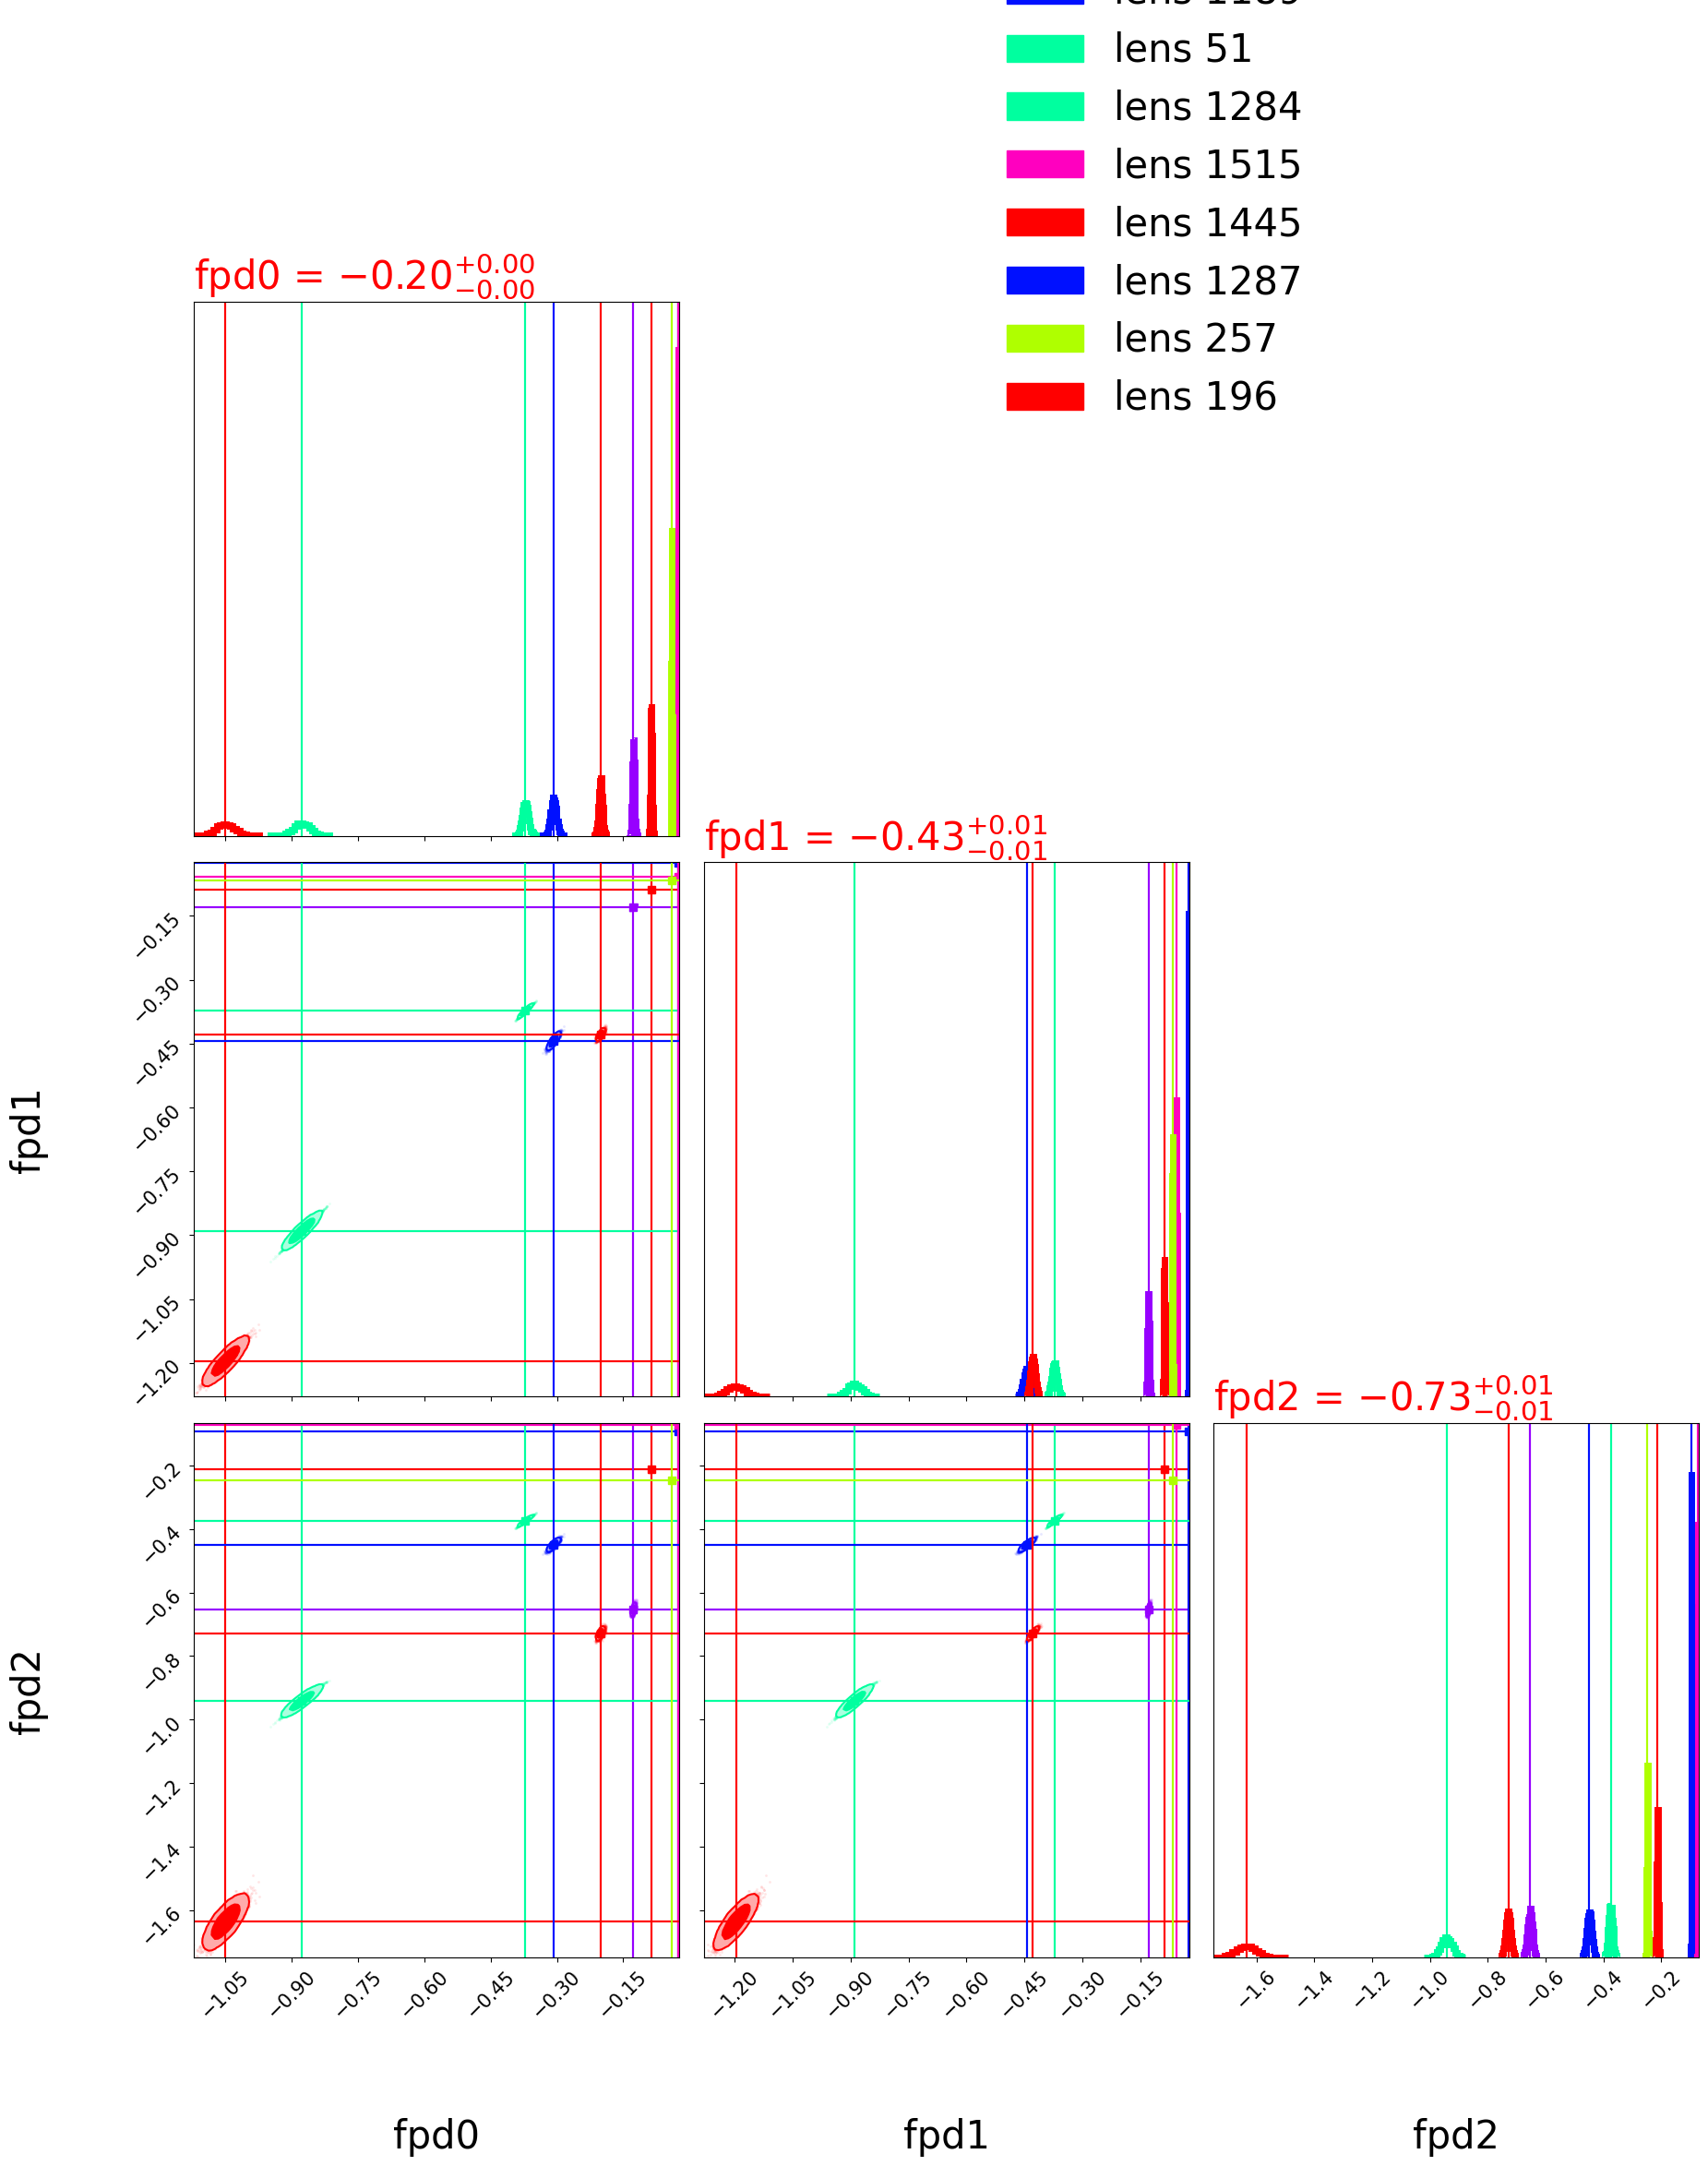

In [33]:
make_contour([np.array(index0['fpd_samples'][i]) for i in range(len(index0['catalog_idxs']))], labels=['fpd0', 'fpd1', 'fpd2'], categories=[f'lens {i}' for i in index0['catalog_idxs']], colors=cols)

In [20]:
import h5py
with h5py.File('Experiments/lsst_forecast/InferenceRuns/exp0_2/2TESTCODE_w0wa_seed6_backend.h5', 'r') as hf:
    chains = hf['mcmc']['chain'][:]

In [19]:
import matplotlib.pyplot as plt

In [21]:
chains_trunc = chains[200:, :, :]

In [22]:
chains_reshaped = chains_trunc.reshape(-1, 10)

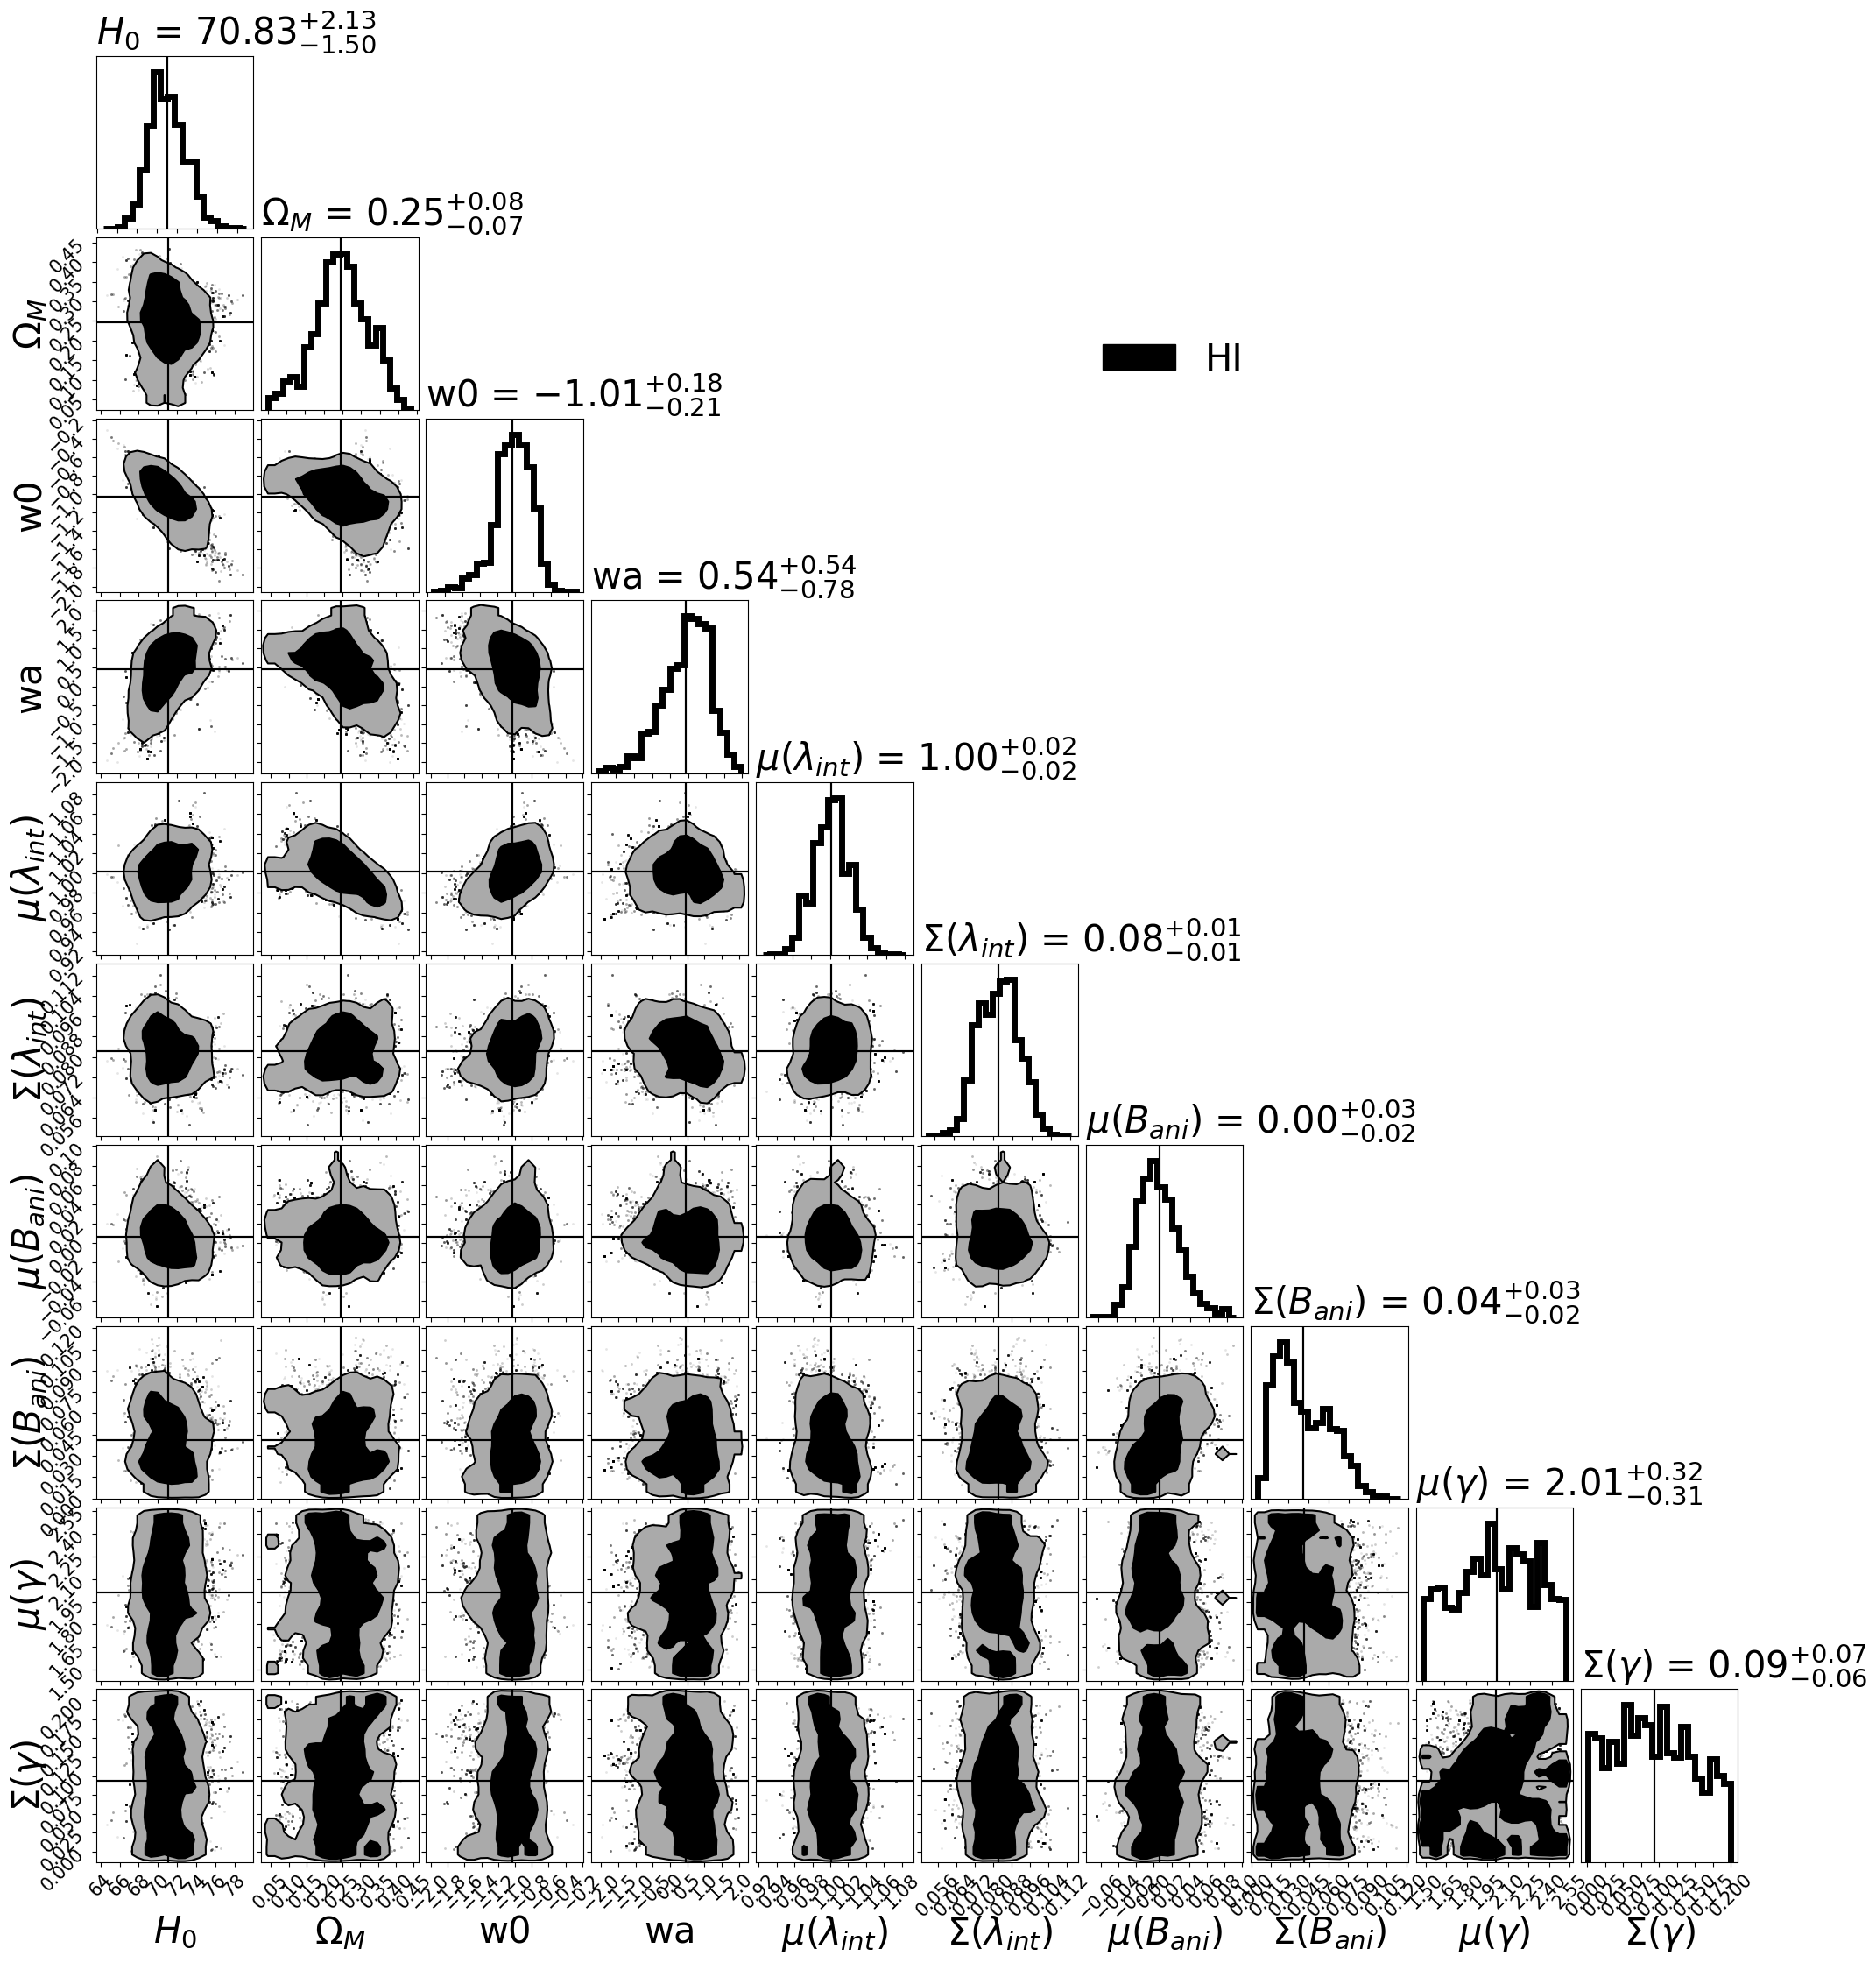

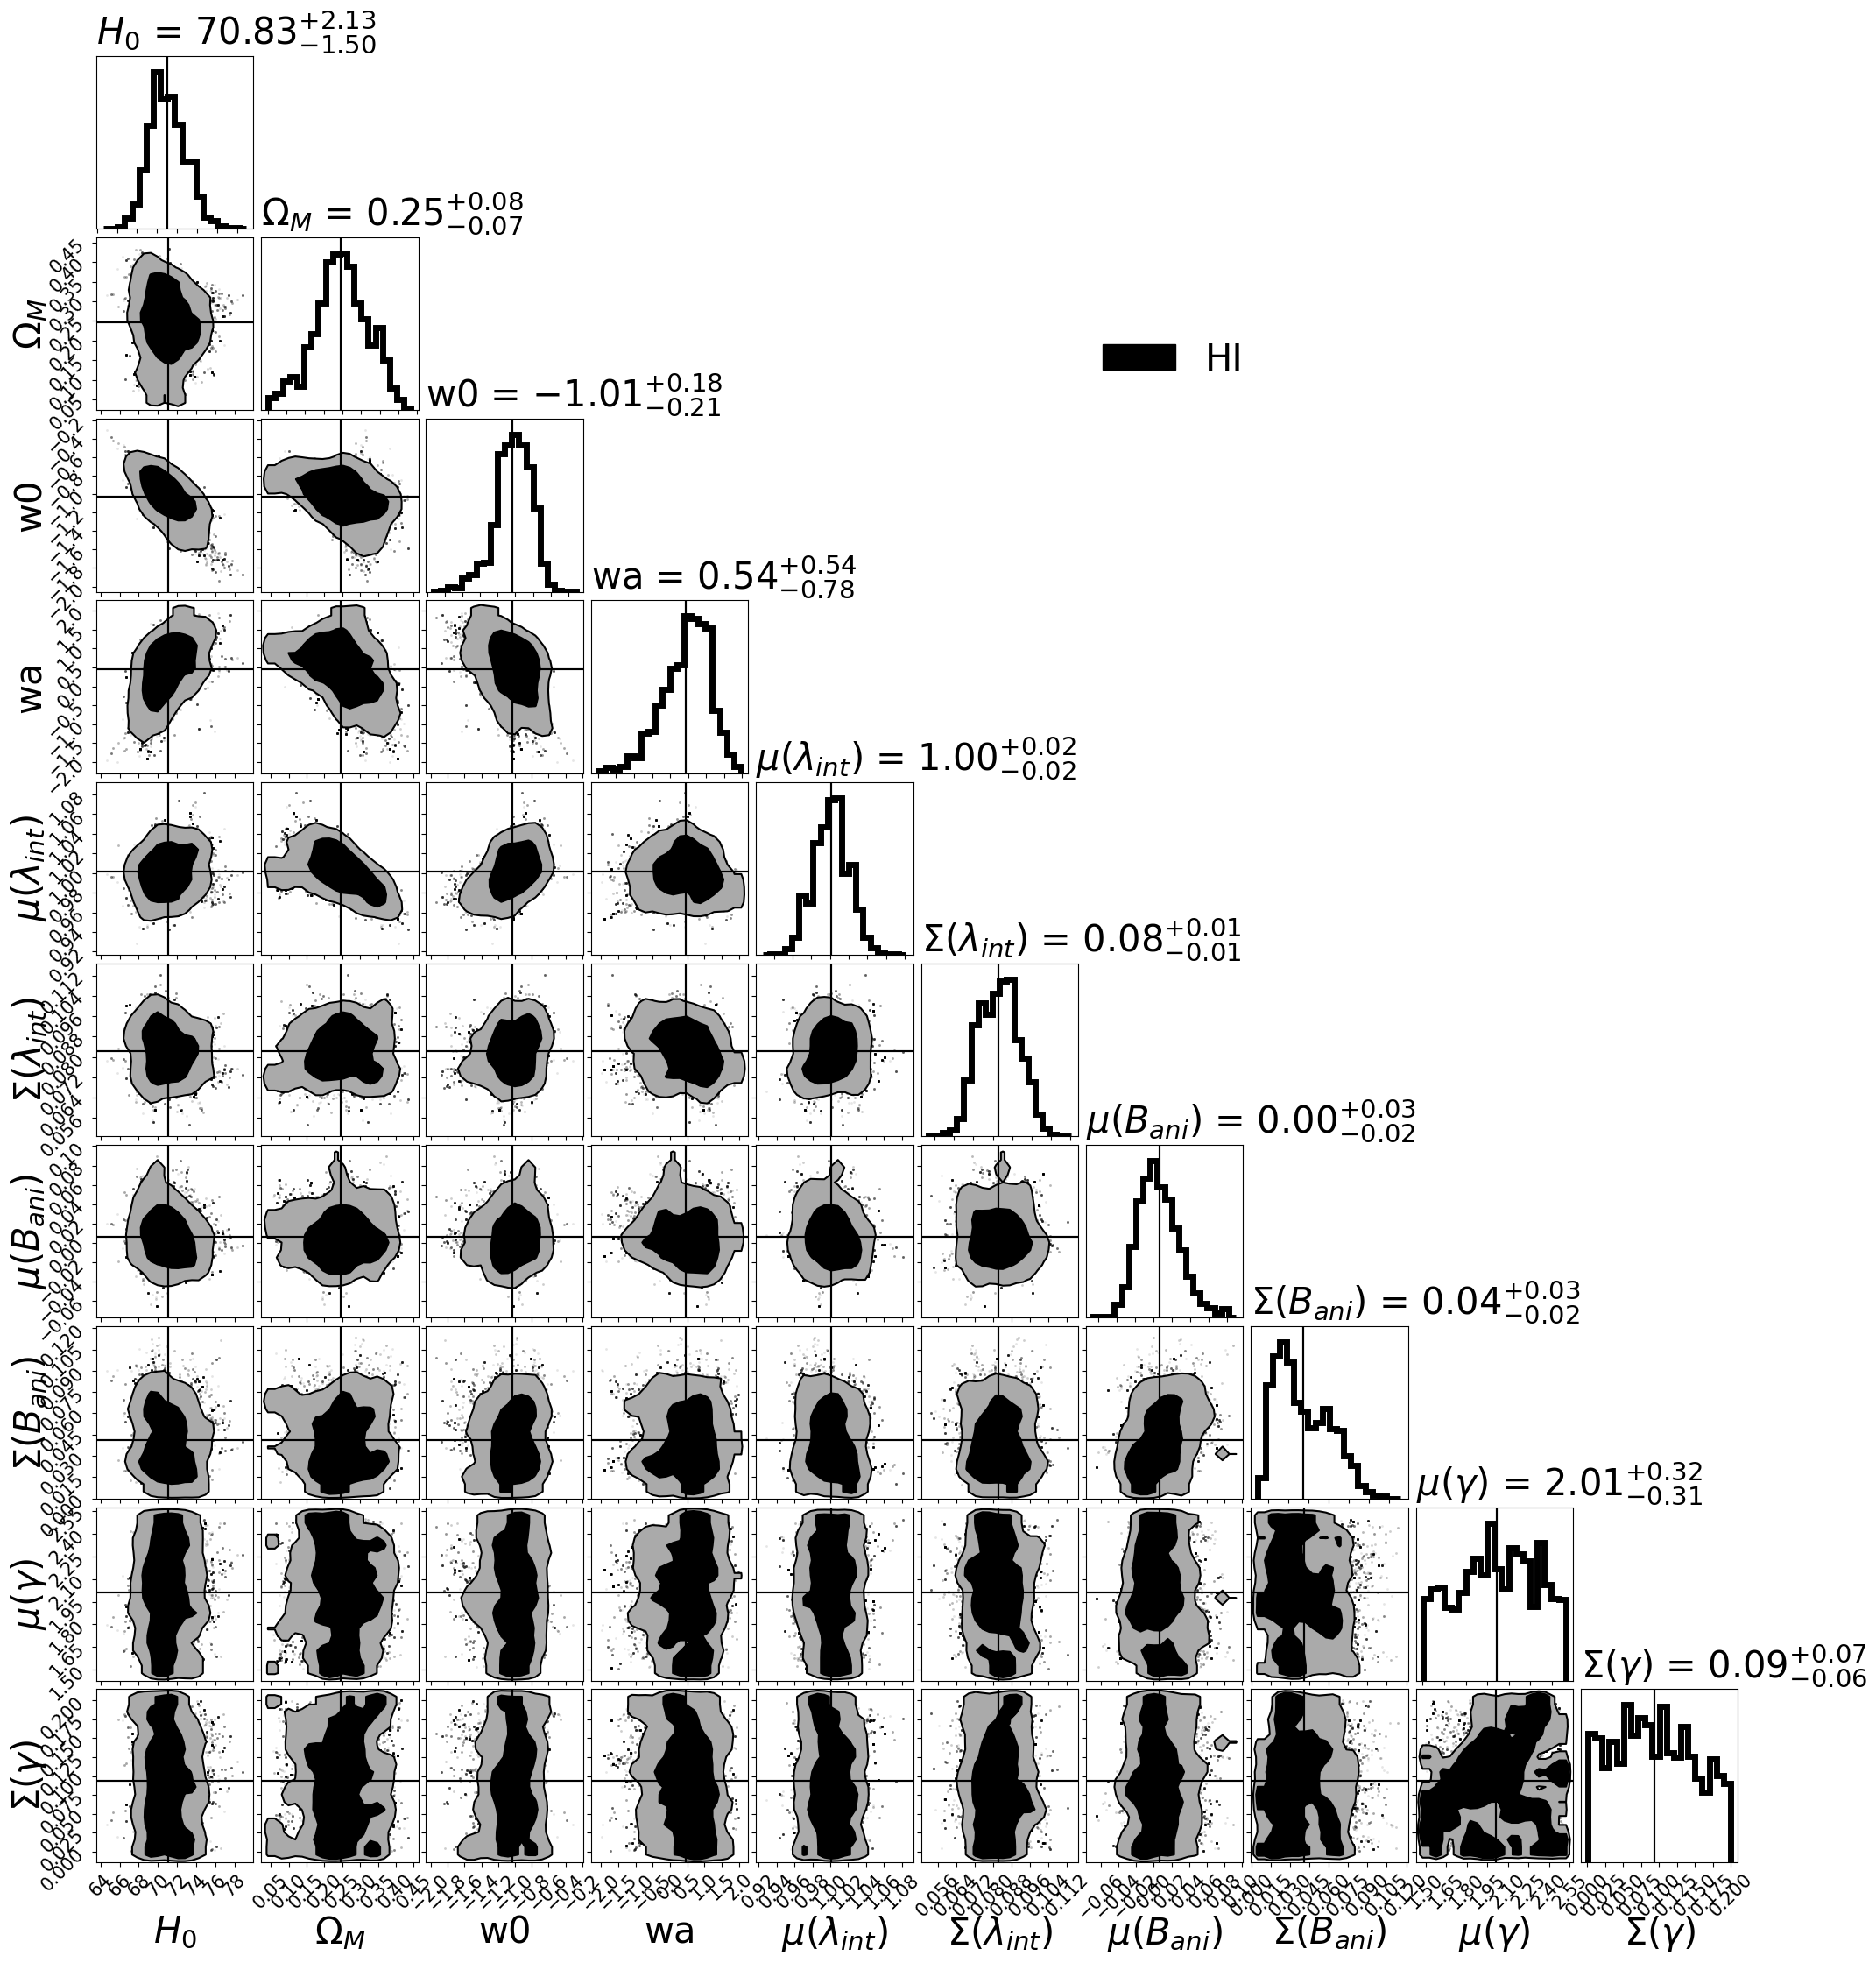

In [32]:
make_contour([chains_reshaped], labels=['$H_0$','$\Omega_M$','w0', 'wa', '$\mu(\lambda_{int})$','$\Sigma(\lambda_{int})$',
            '$\mu(B_{ani})$', "$\Sigma(B_{ani})$",'$\mu(\gamma)$','$\Sigma(\gamma)$'], categories=['HI'], colors=['k'])